# Тема 13. Логический вывод на онтологии (Reasoning)

**Домен:** учебная онтология «Семейные связи».
**Автор:** Анастасия Могилёва.
**Дата:** 2026-05-01. **Версия:** 1.0.

## Аннотация
Ноутбук строит OWL-онтологию из CSV starter-pack'а, запускает DL-reasoner
(HermiT/Pellet через `owlready2`) и демонстрирует, как свойства
**Transitive / Inverse / Symmetric / subPropertyOf** материализуют новые ABox-факты.
Прогоняется 5 SPARQL-запросов разной сложности (rdf:type / транзитивность /
инверсия / симметрия / цепочка) — для каждого фиксируется снимок «до» и «после»
reasoning. Доказывается:

* reasoner запущен, онтология консистентна;
* ≥ 3 запросов дают непустой результат после reasoning;
* ≥ 3 inferred facts появляются именно из аксиом, а не из исходных данных.

Все KPI и артефакты сохраняются в `artifacts/`.


## 0. Bootstrap (Colab / standalone)

Если ноутбук открыт **прямо в Colab** — рядом нет `starter_pack/`. Эта ячейка
идемпотентно подтягивает данные из **публичной Google-Drive-папки автора**
через `gdown` (без авторизации, работает у любого пользователя), при отказе —
fallback на `git clone` из публичного репозитория. Локально (`starter_pack/`
уже рядом) — ничего не делает.

> **Важно для воспроизводимости:** в указанной Drive-папке должна быть папка
> `Тема13_reasoning/` с вложенным `starter_pack/`. Если структура другая —
> поправь `DRIVE_FOLDER_ID` или `GITHUB_BRANCH` ниже.


In [1]:
import os, sys, subprocess
from pathlib import Path

# Источники данных (приоритет: Drive → GitHub)
DRIVE_FOLDER_ID = "1s5BBdVmhoZOk7-OmgsuZnT0zZ510X-PC"      # публичная папка автора
GITHUB_REPO     = "amogilev1993/anastasia_mogileva_project"
GITHUB_BRANCH   = "claude/unified-notebook-template-oJsCY"

IN_COLAB = "google.colab" in sys.modules


def _ensure_pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


def _try_drive_download(folder_id: str, dest: str) -> Path | None:
    '''Качает публичную Drive-папку через gdown. Возвращает путь к каталогу,
    содержащему starter_pack/, или None если не удалось.'''
    try:
        import gdown  # noqa: F401
    except ImportError:
        _ensure_pip("gdown")
        import gdown  # noqa: F401
    try:
        gdown.download_folder(id=folder_id, output=dest,
                              quiet=False, use_cookies=False)
    except Exception as e:
        print(f"[drive] не удалось скачать: {type(e).__name__}: {e}")
        return None
    found = next(iter(Path(dest).rglob("starter_pack")), None)
    return found.parent if (found and found.is_dir()) else None


def _try_git_clone(repo: str, branch: str, dest: str) -> Path | None:
    '''Fallback: shallow git clone репозитория. Возвращает Тема13_reasoning/.'''
    if not Path(dest).exists():
        try:
            subprocess.check_call([
                "git", "clone", "--depth", "1", "-b", branch,
                f"https://github.com/{repo}.git", dest,
            ])
        except Exception as e:
            print(f"[git] не удалось склонировать: {type(e).__name__}: {e}")
            return None
    candidate = Path(dest) / "Тема13_reasoning"
    return candidate if (candidate / "starter_pack").exists() else None


if not Path("starter_pack").exists():
    print("starter_pack/ не найден рядом с ноутбуком — подтягиваю данные…")
    base = "/content" if IN_COLAB else "."
    target = (
        _try_drive_download(DRIVE_FOLDER_ID, f"{base}/_drive")
        or _try_git_clone(GITHUB_REPO, GITHUB_BRANCH, f"{base}/_repo")
    )
    if target is None:
        raise FileNotFoundError(
            "Не удалось загрузить starter_pack ни из Drive, ни из GitHub. "
            "Проверь сеть или загрузи папку вручную."
        )
    os.chdir(target)
    print(f"cwd → {Path.cwd()}")
else:
    print(f"starter_pack/ найден в {Path('starter_pack').resolve()}")

# Зависимости
try:
    import owlready2, rdflib, pandas, matplotlib, networkx, pydantic  # noqa: F401
except ImportError:
    print("Устанавливаю зависимости…")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "owlready2", "rdflib", "pandas", "matplotlib", "networkx", "pydantic",
    ])

print("\nfinal cwd:", Path.cwd())
print("starter_pack exists:", Path("starter_pack").exists())


starter_pack/ найден в /home/user/anastasia_mogileva_project/Тема13_reasoning/starter_pack



final cwd: /home/user/anastasia_mogileva_project/Тема13_reasoning
starter_pack exists: True


## 1. Цель, входы/выходы, критерии приёмки

### Цель
Показать, как DL-reasoner получает **новые знания** из явно записанной семантики
свойств (transitive / inverse / symmetric / subProperty), без явного перечисления
всех троек. Это базовый паттерн представления знаний в knowledge-based ИИС.

### Входы (`starter_pack/`)
| Путь | Описание |
|---|---|
| `data/individuals.csv` | 5 индивидов с классом `Male`/`Female` |
| `data/relationships.csv` | 5 явных троек (только `hasParent` и `hasSibling`) |
| `kb/ontology_seed_terms.csv` | TBox-термины + характеристики свойств |
| `kb/ontology_axioms.md` | человекочитаемое описание ожиданий |
| `tests/queries.txt` | 5 SPARQL-запросов |
| `tests/expected.json` | эталоны before/after, минимумы по KPI |

### Выходы (`artifacts/`)
| Файл | Описание |
|---|---|
| `family.owl` | сгенерированная онтология (RDF/XML) |
| `reasoner_log.txt` | какой reasoner выбран + время + статус |
| `queries_results.csv` | таблица 5 запросов: запрос → before → after → интерпретация |
| `inferred_facts.json` | новые ABox-факты с указанием правила вывода |
| `ontology_diff.png` | граф связей до/после reasoning |
| `report.md` | мини-отчёт (1–2 страницы) |
| `kpi_report.csv` | KPI с PASS/FAIL |
| `input_profile.json` | паспорт входных данных |
| `architecture.mmd` | Mermaid-диаграмма архитектуры |
| `results.csv` | унифицированный snapshot результатов |
| `export_summary.txt` | список всех артефактов |

### KPI
| KPI | Определение | Порог | Где измеряем |
|---|---|---|---|
| `reasoner_started` | reasoner отработал без исключений (Pellet/HermiT, либо ручное замыкание) | OK | секция 7, лог |
| `queries_count` | число прогнанных SPARQL-запросов | == 5 | секция 7 |
| `queries_nonempty_after` | сколько запросов дали непустой результат после reasoning | ≥ 3 | `evaluate()` |
| `inferred_facts` | сколько новых ABox-троек добавил reasoner | ≥ 3 | diff `before/after` |
| `ontology_consistent` | в онтологии нет индивидов, попавших в `owl:Nothing` | True | `evaluate()` |

### Acceptance criteria (Given/When/Then)
1. **Given** starter-pack без выведенных свойств, **when** запускаем reasoner,
   **then** для `Dmitry hasAncestor ?x` ответ = `{Anna, Boris}` (транзитивность).
2. **Given** только `hasParent`-тройки, **when** reasoning,
   **then** `Anna hasChild ?x` = `{Boris, Clara}` (inverse).
3. **Given** одна тройка `Boris hasSibling Clara`, **when** reasoning,
   **then** `Clara hasSibling Boris` тоже выводится (symmetric).
4. **Given** запрос-цепочка `hasChild ∘ hasChild`, **when** reasoning,
   **then** внуки Анны = `{Dmitry, Elena}`.
5. **Given** консистентная онтология, **when** reasoner,
   **then** ни один индивид не помещается в `owl:Nothing`.


## 2. Среда выполнения и воспроизводимость

In [2]:
# Если запускаете в Colab без зависимостей — раскомментируйте:
# !pip -q install owlready2 rdflib pandas matplotlib networkx pydantic
import sys, os, json, time, random
from pathlib import Path
from importlib.metadata import version as _v

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import rdflib
from rdflib import Graph as RDFGraph, Namespace, Literal
from rdflib.namespace import RDF, RDFS, OWL
import owlready2
from owlready2 import (
    get_ontology, Thing, ObjectProperty, TransitiveProperty,
    SymmetricProperty, AllDisjoint, default_world,
    sync_reasoner_pellet, sync_reasoner,
)

CONFIG = {
    "seed": 42,
    "data_path":      "starter_pack/data",
    "kb_path":        "starter_pack/kb",
    "tests_path":     "starter_pack/tests",
    "artifacts_path": "artifacts",
    "ontology_iri":   "http://example.org/family.owl",
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

print(f"python      : {sys.version.split()[0]}")
print(f"owlready2   : {_v('owlready2')}")
print(f"rdflib      : {_v('rdflib')}")
print(f"pandas      : {pd.__version__}")
print(f"networkx    : {nx.__version__}")
print(f"matplotlib  : {plt.matplotlib.__version__}")

ART = Path(CONFIG["artifacts_path"])
ART.mkdir(exist_ok=True, parents=True)
print(f"\nartifacts dir: {ART.resolve()}")


python      : 3.11.15
owlready2   : 0.50
rdflib      : 7.6.0
pandas      : 3.0.2
networkx    : 3.6.1
matplotlib  : 3.10.9

artifacts dir: /home/user/anastasia_mogileva_project/Тема13_reasoning/artifacts


## 3. Загрузка starter-pack и первичная валидация

Проверяем наличие всех ожидаемых файлов, корректность схемы CSV, ссылочную
целостность (subject/object из `relationships.csv` действительно существуют в
`individuals.csv`) и сохраняем «паспорт входов» в `artifacts/input_profile.json`.


In [3]:
DATA  = Path(CONFIG["data_path"])
KB    = Path(CONFIG["kb_path"])
TESTS = Path(CONFIG["tests_path"])

required = [
    DATA/"individuals.csv", DATA/"relationships.csv",
    KB/"ontology_seed_terms.csv",
    TESTS/"queries.txt", TESTS/"cases.csv", TESTS/"expected.json",
]
missing = [str(p) for p in required if not p.exists()]
assert not missing, f"missing starter-pack files: {missing}"

individuals   = pd.read_csv(DATA/"individuals.csv")
relationships = pd.read_csv(DATA/"relationships.csv")
seed_terms    = pd.read_csv(KB/"ontology_seed_terms.csv")
expected      = json.loads((TESTS/"expected.json").read_text(encoding="utf-8"))

# схема
assert {"id","class","label"} <= set(individuals.columns)
assert {"subject","predicate","object"} <= set(relationships.columns)
assert individuals["class"].isin({"Male","Female"}).all(), "unknown class"
assert relationships["predicate"].isin(
    {"hasParent","hasChild","hasAncestor","hasSibling"}
).all(), "unknown predicate"
assert individuals["id"].is_unique, "duplicate individual ids"

# ссылочная целостность
ids = set(individuals["id"])
bad = relationships[~relationships["subject"].isin(ids)
                    | ~relationships["object"].isin(ids)]
assert bad.empty, f"dangling refs:\n{bad}"

profile = {
    "individuals":           int(len(individuals)),
    "relationships":         int(len(relationships)),
    "classes":               sorted(individuals["class"].unique().tolist()),
    "predicates_in_data":    sorted(relationships["predicate"].unique().tolist()),
    "missing_cells":         int(individuals.isnull().sum().sum())
                              + int(relationships.isnull().sum().sum()),
    "tbox_terms":            int(len(seed_terms)),
}
(ART/"input_profile.json").write_text(
    json.dumps(profile, ensure_ascii=False, indent=2), encoding="utf-8")

print(json.dumps(profile, ensure_ascii=False, indent=2))
display(individuals)
display(relationships)


{
  "individuals": 5,
  "relationships": 5,
  "classes": [
    "Female",
    "Male"
  ],
  "predicates_in_data": [
    "hasParent",
    "hasSibling"
  ],
  "missing_cells": 0,
  "tbox_terms": 7
}


,id,class,label,note
0,Anna,Female,Анна,старшее поколение
1,Boris,Male,Борис,сын Анны
2,Clara,Female,Клара,дочь Анны
3,Dmitry,Male,Дмитрий,сын Бориса
4,Elena,Female,Елена,дочь Клары


,subject,predicate,object,note
0,Boris,hasParent,Anna,явный факт
1,Clara,hasParent,Anna,явный факт
2,Dmitry,hasParent,Boris,явный факт
3,Elena,hasParent,Clara,явный факт
4,Boris,hasSibling,Clara,явный факт


## 4. Теоретическая часть

### Ключевые тезисы
1. **Reasoning ≠ запрос.** SPARQL только спрашивает граф — он не делает
   логических выводов. Новые тройки появляются только тогда, когда reasoner
   применяет аксиомы TBox к ABox.
2. **Описательные логики (DL).** OWL DL — фрагмент логики предикатов первого
   порядка с разрешимыми задачами consistency / classification / instance
   checking. HermiT и Pellet — табличные ризонеры для OWL 2 DL.
3. **Property characteristics — четыре «бесплатных» рычага вывода:**
   * `TransitiveProperty`: `P(a,b) ∧ P(b,c) ⇒ P(a,c)` — пример: `hasAncestor`.
   * `InverseObjectProperty`: `P⁻(b,a) ⇔ P(a,b)` — пример: `hasChild ≡ hasParent⁻¹`.
   * `SymmetricProperty`: `P(a,b) ⇒ P(b,a)` — пример: `hasSibling`.
   * `rdfs:subPropertyOf`: `P ⊑ Q ⇒ P(a,b) ⇒ Q(a,b)` — пример: `hasParent ⊑ hasAncestor`.
4. **Materialization vs query rewriting.** Owlready2 + HermiT/Pellet работают
   через **materialization**: после `sync_reasoner(infer_property_values=True)`
   выведенные тройки физически добавляются в `default_world`. Альтернатива —
   query rewriting (Stardog, RDFox) — переписывает SPARQL под аксиомы на лету.
5. **Open World Assumption (OWA).** В OWL отсутствие факта ≠ отрицание.
   Поэтому пустой ответ SPARQL до reasoning ничего не доказывает — нужно либо
   явное `owl:differentFrom`, либо closed-world расширение (CWA / SWRL / SHACL).

### Источники
* W3C — *OWL 2 Web Ontology Language Primer*, 2012. <https://www.w3.org/TR/owl2-primer/>
* W3C — *SPARQL 1.1 Query Language*, 2013. <https://www.w3.org/TR/sparql11-query/>
* Lamy J.-B. — *Owlready: Ontology-oriented programming in Python*, AI in Medicine 80, 2017.
* Glimm B., Horrocks I., Motik B., Stoilos G., Wang Z. — *HermiT: An OWL 2 Reasoner*, JAR 53(3), 2014.
* Sirin E. et al. — *Pellet: A practical OWL-DL reasoner*, JWS 5(2), 2007.
* Horridge M., Bechhofer S. — *The OWL API: A Java API for OWL ontologies*, SWJ, 2011.

### Ограничения подхода
1. **Производительность.** Materialization экспоненциально растёт от глубины
   аксиом и числа индивидов; для сотен тысяч узлов нужен либо профилизация
   (OWL 2 EL/RL), либо query rewriting.
2. **OWA + плоский домен.** В семейных связях OWA удобна, но в задачах
   рекомендаций или контроля доступа отсутствие факта надо трактовать как «нет»
   (CWA), что требует отдельного слоя правил (SWRL/SHACL).
3. **Выразительность Symmetric+Transitive комбинации ограничена** — некоторые
   property chains в OWL 2 DL запрещены, чтобы сохранить разрешимость.


## 5. Проектирование (Design)

### Мини-архитектура решения

```mermaid
flowchart LR
    subgraph Inputs[starter_pack/]
        IND[individuals.csv]
        REL[relationships.csv]
        TBOX[ontology_seed_terms.csv]
        Q[queries.txt]
    end
    subgraph Build[Build & Reason]
        B1[build_ontology<br/>TBox + ABox]
        B2[snapshot rdflib BEFORE]
        B3[run_reasoner<br/>Pellet → HermiT → manual]
        B4[snapshot rdflib AFTER]
    end
    subgraph Eval[Evaluate]
        E1[run 5 SPARQL до/после]
        E2[diff inferred facts]
        E3[evaluate KPI]
    end
    subgraph Out[artifacts/]
        A1[family.owl]
        A2[queries_results.csv]
        A3[inferred_facts.json]
        A4[ontology_diff.png]
        A5[kpi_report.csv]
        A6[report.md]
    end
    Inputs --> B1 --> B2 --> B3 --> B4
    B4 --> E1 --> E2 --> E3
    B1 --> A1
    E1 --> A2
    E2 --> A3
    B4 --> A4
    E3 --> A5
    E3 --> A6
```

### Контракт данных
| Источник | Преобразование | Цель |
|---|---|---|
| `individuals.csv` | по строке → `Male(id)` или `Female(id)` | ABox: классы индивидов |
| `relationships.csv` | по строке → `subject.predicate.append(object)` | ABox: object property assertions |
| `ontology_seed_terms.csv` | используется как документация TBox | TBox задан в коде |
| `queries.txt` | парсер маркеров `=== Qx :: …` | список SPARQL-блоков |

### Допущения
1. Размер ABox мал, materialization дёшев → нет смысла в query rewriting.
2. Reasoner: предпочитаем Pellet (быстрее на маленьких онтологиях, поставляется
   с `owlready2`), при сбое — HermiT, при отсутствии Java — ручное замыкание.
3. ABox-факты выводятся ровно по 4 правилам, см. `RULE_BY_PRED`.


In [4]:
# Сохраняем источник Mermaid-диаграммы (тот же блок, что выше — без обрамления ```mermaid)
ARCH_MMD = '''flowchart LR
    subgraph Inputs[starter_pack/]
        IND[individuals.csv]
        REL[relationships.csv]
        TBOX[ontology_seed_terms.csv]
        Q[queries.txt]
    end
    subgraph Build[Build & Reason]
        B1[build_ontology TBox + ABox]
        B2[snapshot rdflib BEFORE]
        B3[run_reasoner Pellet/HermiT/manual]
        B4[snapshot rdflib AFTER]
    end
    subgraph Eval[Evaluate]
        E1[run 5 SPARQL до/после]
        E2[diff inferred facts]
        E3[evaluate KPI]
    end
    subgraph Out[artifacts/]
        A1[family.owl]
        A2[queries_results.csv]
        A3[inferred_facts.json]
        A4[ontology_diff.png]
        A5[kpi_report.csv]
        A6[report.md]
    end
    Inputs --> B1 --> B2 --> B3 --> B4
    B4 --> E1 --> E2 --> E3
    B1 --> A1
    E1 --> A2
    E2 --> A3
    B4 --> A4
    E3 --> A5
    E3 --> A6
'''
(ART/"architecture.mmd").write_text(ARCH_MMD, encoding="utf-8")
print("saved:", ART/"architecture.mmd")


saved: artifacts/architecture.mmd


## 6. Реализация

Модули решения:

* `build_raw_rdflib(individuals, relationships, iri)` — собирает «сырой»
  rdflib-граф **только из явных троек** CSV. Нужен для честного снимка BEFORE,
  потому что owlready2 на этапе `obj.prop.append(...)` сам материализует
  inverse/symmetric — и `as_rdflib_graph()` будет уже «загрязнён» автовыводами.
* `build_owlready_world(individuals, relationships, iri)` — строит полный
  TBox (классы + свойства с характеристиками: Transitive / Inverse /
  Symmetric / subPropertyOf) и ABox.
* `snapshot_rdflib(world)` — иммутабельная копия `world` как `rdflib.Graph`.
* `materialize_semantics(onto)` — применяет 4 правила вывода. Используется
  и как **fallback** (если ни Pellet, ни HermiT не запустились), и как
  **post-processing** после reasoner'а — потому что owlready2 после `sync_reasoner`
  возвращает в quadstore только изменения «загруженных в Python» сущностей и
  систематически опускает inferred-`hasAncestor`.
* `run_reasoner(onto, world, log)` — пробует **Pellet → HermiT → fallback**.
  Логирует попытки, возвращает имя выбранного движка.
* `run_sparql(graph, sparql_text)` — выполняет SPARQL с автоматически
  подмешанными префиксами, нормализует URI до коротких имён.
* `evaluate()` — вычисляет KPI и сохраняет `kpi_report.csv`.


In [5]:
# --- 1. "Сырой" мир: только то, что записано в CSV (без owlready2-runtime) ---
# Нужен для честного снимка BEFORE — owlready2 при ассертах автоматически
# материализует inverse/symmetric, что портит "до".
def build_raw_rdflib(individuals_df, relationships_df, iri):
    NS = Namespace(iri + "#")
    g = RDFGraph()
    g.bind("", NS); g.bind("rdf", RDF); g.bind("rdfs", RDFS); g.bind("owl", OWL)
    # TBox declarations
    g.add((NS["Person"], RDF.type, OWL.Class))
    for cls in ["Male", "Female"]:
        g.add((NS[cls], RDF.type, OWL.Class))
        g.add((NS[cls], RDFS.subClassOf, NS["Person"]))
    for prop in ["hasParent", "hasChild", "hasAncestor", "hasSibling"]:
        g.add((NS[prop], RDF.type, OWL.ObjectProperty))
    # ABox: только явные факты из CSV
    for _, r in individuals_df.iterrows():
        g.add((NS[r["id"]], RDF.type, NS[r["class"]]))
        g.add((NS[r["id"]], RDFS.label, Literal(r["label"])))
    for _, r in relationships_df.iterrows():
        g.add((NS[r["subject"]], NS[r["predicate"]], NS[r["object"]]))
    return g


# --- 2. Полный owlready2-мир: TBox с характеристиками свойств + ABox ---
def build_owlready_world(individuals_df, relationships_df, iri):
    world = owlready2.World()
    onto = world.get_ontology(iri)
    with onto:
        class Person(Thing): pass
        class Male(Person):  pass
        class Female(Person): pass
        AllDisjoint([Male, Female])

        # hasAncestor — TRANSITIVE; hasParent ⊑ hasAncestor, но сам НЕ транзитивный
        # (родитель родителя — не «родитель», но «предок»).
        class hasAncestor(ObjectProperty, TransitiveProperty):
            domain = [Person]; range = [Person]
        class hasParent(hasAncestor):
            domain = [Person]; range = [Person]
        class hasChild(ObjectProperty):
            domain = [Person]; range = [Person]
            inverse_property = hasParent
        class hasSibling(ObjectProperty, SymmetricProperty):
            domain = [Person]; range = [Person]

    cls_map = {"Male": onto.Male, "Female": onto.Female}
    inds = {}
    for _, r in individuals_df.iterrows():
        ind = cls_map[r["class"]](r["id"])
        ind.label = [str(r["label"])]
        inds[r["id"]] = ind

    for _, r in relationships_df.iterrows():
        getattr(inds[r["subject"]], r["predicate"]).append(inds[r["object"]])
    return onto, world, inds


def snapshot_rdflib(world) -> RDFGraph:
    g = RDFGraph()
    src = world.as_rdflib_graph()
    for prefix, ns in src.namespaces():
        g.bind(prefix, ns)
    for t in src:
        g.add(t)
    return g


In [6]:
def materialize_semantics(onto):
    '''Идемпотентно применяет 4 правила (subProperty, inverse, symmetric, transitive).
    Используется и как fallback (когда reasoner недоступен), и как пост-обработка
    после HermiT/Pellet — потому что reasoner возвращает в quadstore owlready2
    только изменения "загруженных в Python" сущностей и часто опускает
    inferred hasAncestor.'''
    persons = list(onto.Person.instances())
    # 1. subPropertyOf: hasParent ⊑ hasAncestor
    for ind in persons:
        for p in list(ind.hasParent):
            if p not in ind.hasAncestor:
                ind.hasAncestor.append(p)
    # 2. inverse: hasChild ≡ hasParent⁻¹  (owlready2 уже делает на ассерте,
    #    но reasoner может добавить новые hasParent — для них нужен и inverse)
    for ind in persons:
        for p in list(ind.hasParent):
            if ind not in p.hasChild:
                p.hasChild.append(ind)
    # 3. symmetric: hasSibling
    for ind in persons:
        for s in list(ind.hasSibling):
            if ind not in s.hasSibling:
                s.hasSibling.append(ind)
    # 4. transitive closure on hasAncestor
    changed = True
    while changed:
        changed = False
        for ind in persons:
            current = set(ind.hasAncestor)
            new = {aa for a in current for aa in a.hasAncestor
                   if aa not in current and aa is not ind}
            for n in new:
                ind.hasAncestor.append(n)
                changed = True


def run_reasoner(onto, world, log: list) -> str:
    '''Pellet → HermiT → fallback. После любого успешного reasoner-а ещё запускается
    materialize_semantics (для гарантированного попадания inferred-троек в quadstore).'''
    chosen = None
    for name, fn in [
        ("Pellet", lambda: sync_reasoner_pellet(world, infer_property_values=True)),
        ("HermiT", lambda: sync_reasoner(world, infer_property_values=True)),
    ]:
        t0 = time.time()
        try:
            with onto:
                fn()
            log.append({"reasoner": name, "status": "OK",
                        "seconds": round(time.time() - t0, 3)})
            chosen = name
            break
        except Exception as e:
            log.append({"reasoner": name,
                        "status": f"FAIL: {type(e).__name__}: {str(e)[:160]}",
                        "seconds": round(time.time() - t0, 3)})

    # Пост-обработка / fallback
    t1 = time.time()
    materialize_semantics(onto)
    log.append({"reasoner": "materialize_semantics" + (" (post)" if chosen else " (fallback)"),
                "status": "OK", "seconds": round(time.time() - t1, 3)})
    return chosen or "manual_closure"


In [7]:
def load_queries(path):
    text = Path(path).read_text(encoding="utf-8")
    blocks, cur = [], None
    for line in text.splitlines():
        if line.startswith("==="):
            if cur:
                blocks.append(cur)
            header = line.strip("= ").strip()
            parts  = [x.strip() for x in header.split("::")]
            cur = {
                "id":     parts[0] if len(parts) > 0 else "?",
                "type":   parts[1] if len(parts) > 1 else "",
                "desc":   parts[2] if len(parts) > 2 else "",
                "sparql": "",
            }
        elif cur is not None and line.strip() and not line.startswith("#"):
            cur["sparql"] += line + "\n"
    if cur:
        blocks.append(cur)
    return blocks


PREFIXES = (
    f"PREFIX : <{CONFIG['ontology_iri']}#>\n"
    f"PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>\n"
    f"PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>\n"
    f"PREFIX owl:  <http://www.w3.org/2002/07/owl#>\n"
)

def short(uri) -> str:
    s = str(uri)
    if "#" in s: return s.rsplit("#", 1)[1]
    if "/" in s: return s.rsplit("/", 1)[1]
    return s

def run_sparql(graph: RDFGraph, sparql_text: str):
    full = PREFIXES + sparql_text
    rows = []
    for r in graph.query(full):
        rows.append(tuple(short(v) for v in r))
    return sorted(set(rows))


EXPLANATIONS = {
    "Q1": "rdf:type не требует reasoning — Male указан явно у Boris и Dmitry.",
    "Q2": ("До reasoning hasAncestor у Dmitry пуст. После — добавляются Boris "
           "(по subPropertyOf hasParent⊑hasAncestor) и Anna (по транзитивности)."),
    "Q3": "До reasoning hasChild не задан явно. После — материализуется как inverse_property от hasParent.",
    "Q4": "До reasoning только Boris→Clara. После — symmetric делает обратное Clara→Boris.",
    "Q5": ("Цепочка hasChild∘hasChild требует, чтобы оба hasChild были выведены "
           "reasoner'ом из inverse hasParent. Внуки Анны: Dmitry, Elena."),
}
RULE_BY_PRED = {
    "hasChild":    "inverse_property",
    "hasAncestor": "subPropertyOf+transitive",
    "hasSibling":  "symmetric",
    "hasParent":   "transitive",
}


## 7. Эксперименты / Демонстрационные сценарии

Сценарий простой и универсальный для всех 5 запросов:
1. строим онтологию в чистом `World`;
2. фиксируем снимок `g_before`;
3. **прогоняем все 5 запросов до reasoning**;
4. запускаем reasoner;
5. фиксируем снимок `g_after`;
6. **прогоняем все 5 запросов после reasoning**;
7. вычисляем diff троек и формируем `inferred_facts.json`.


In [8]:
log = []

# BEFORE — пустая семантика, только явные тройки
g_before = build_raw_rdflib(individuals, relationships, CONFIG["ontology_iri"])

queries  = load_queries(TESTS/"queries.txt")
print("queries loaded:", [q["id"] for q in queries])
assert len(queries) == 5, f"expected 5 queries, got {len(queries)}"

before = {q["id"]: run_sparql(g_before, q["sparql"]) for q in queries}

# AFTER — полная онтология + reasoner + materialize
onto, world, inds = build_owlready_world(individuals, relationships, CONFIG["ontology_iri"])
reasoner_name = run_reasoner(onto, world, log)
print(f"\nreasoner used: {reasoner_name}")
for entry in log:
    print(f"  {entry['reasoner']:>34s}  {entry['seconds']:>6}s  {entry['status'][:80]}")

g_after = snapshot_rdflib(world)
after  = {q["id"]: run_sparql(g_after, q["sparql"]) for q in queries}

# Сохраняем онтологию и лог
onto.save(file=str(ART/"family.owl"), format="rdfxml")
log_text = "Reasoner attempts log\n" + "=" * 70 + "\n"
for entry in log:
    log_text += f"  {entry['reasoner']:<34}  {entry['status']:<60}  {entry['seconds']}s\n"
log_text += f"\nSelected reasoner: {reasoner_name}\n"
(ART/"reasoner_log.txt").write_text(log_text, encoding="utf-8")
print("\n" + log_text)


queries loaded: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp /usr/local/lib/python3.11/dist-packages/owlready2/pellet/xml-apis-1.4.01.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/antlr-3.2.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/aterm-java-1.6.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/log4j-api-2.19.0.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/jcl-over-slf4j-1.6.4.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/slf4j-log4j12-1.6.4.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/jena-tdb-0.10.0.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/httpclient-4.2.3.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/httpcore-4.2.2.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/commons-codec-1.6.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/antlr-runtime-3.2.jar:/usr/local/lib/python3.11/dist-packages/owlready2/pellet/jgrapht-jdk1.5.jar:/usr/local/lib/

* Owlready2 * Running HermiT...
    java -Xmx2000M -cp /usr/local/lib/python3.11/dist-packages/owlready2/hermit:/usr/local/lib/python3.11/dist-packages/owlready2/hermit/HermiT.jar org.semanticweb.HermiT.cli.CommandLine -c -O -D -I file:////tmp/tmpxjjb9lzy -Y


* Owlready2 * HermiT took 1.3529205322265625 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


* Owlready * Adding relation family.Dmitry hasAncestor family.Anna
* Owlready * Adding relation family.Elena hasAncestor family.Anna

reasoner used: HermiT
                              Pellet   2.873s  FAIL: OwlReadyJavaError: Java error message is:
Exception in thread "main" java.
                              HermiT   1.355s  OK
        materialize_semantics (post)   0.194s  OK



Reasoner attempts log
  Pellet                              FAIL: OwlReadyJavaError: Java error message is:
Exception in thread "main" java.lang.UnsupportedClassVersionError: org/apache/jena/riot/lang/LangRDFXML has been compiled by a more recen  2.873s
  HermiT                              OK                                                            1.355s
  materialize_semantics (post)        OK                                                            0.194s

Selected reasoner: HermiT



In [9]:
# Таблица 5 запросов: до/после/новое + интерпретация
rows = []
for q in queries:
    qid = q["id"]
    b = sorted({r[0] for r in before[qid]}) if before[qid] else []
    a = sorted({r[0] for r in after[qid]})  if after[qid]  else []
    diff = sorted(set(a) - set(b))
    rows.append({
        "query_id": qid,
        "type":     q["type"],
        "description": q["desc"],
        "sparql":   q["sparql"].strip(),
        "before":   ", ".join(b),
        "after":    ", ".join(a),
        "new_after_reasoning": ", ".join(diff),
        "nonempty_after": bool(a),
        "interpretation": EXPLANATIONS.get(qid, ""),
    })
queries_df = pd.DataFrame(rows)
queries_df.to_csv(ART/"queries_results.csv", index=False)
queries_df[["query_id","type","before","after","new_after_reasoning","nonempty_after"]]


,query_id,type,before,after,new_after_reasoning,nonempty_after
0,Q1,простой,"Boris, Dmitry","Boris, Dmitry",,True
1,Q2,транзитивность,,"Anna, Boris","Anna, Boris",True
2,Q3,инверсия,,"Boris, Clara","Boris, Clara",True
3,Q4,симметрия,,Boris,Boris,True
4,Q5,цепочка / смешанный,,"Dmitry, Elena","Dmitry, Elena",True


In [10]:
# Diff троек ABox: что добавилось после reasoning
def abox_triples(g: RDFGraph) -> set:
    out = set()
    for s, p, o in g:
        ps, pp, po = short(s), short(p), short(o)
        if pp in {"hasParent","hasChild","hasAncestor","hasSibling"} \
           and ps in inds and po in inds:
            out.add((ps, pp, po))
    return out

before_t = abox_triples(g_before)
after_t  = abox_triples(g_after)
new_facts = sorted(after_t - before_t)

inferred = [
    {"subject": s, "predicate": p, "object": o, "rule": RULE_BY_PRED.get(p, "?")}
    for (s, p, o) in new_facts
]
(ART/"inferred_facts.json").write_text(
    json.dumps(inferred, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"BEFORE ABox triples: {len(before_t)}")
print(f"AFTER  ABox triples: {len(after_t)}")
print(f"INFERRED facts:      {len(inferred)}\n")
for f in inferred:
    print(f"  + {f['subject']:>7} {f['predicate']:<12} {f['object']:<7}  ({f['rule']})")


BEFORE ABox triples: 5
AFTER  ABox triples: 16
INFERRED facts:      11

  +    Anna hasChild     Boris    (inverse_property)
  +    Anna hasChild     Clara    (inverse_property)
  +   Boris hasAncestor  Anna     (subPropertyOf+transitive)
  +   Boris hasChild     Dmitry   (inverse_property)
  +   Clara hasAncestor  Anna     (subPropertyOf+transitive)
  +   Clara hasChild     Elena    (inverse_property)
  +   Clara hasSibling   Boris    (symmetric)
  +  Dmitry hasAncestor  Anna     (subPropertyOf+transitive)
  +  Dmitry hasAncestor  Boris    (subPropertyOf+transitive)
  +   Elena hasAncestor  Anna     (subPropertyOf+transitive)
  +   Elena hasAncestor  Clara    (subPropertyOf+transitive)


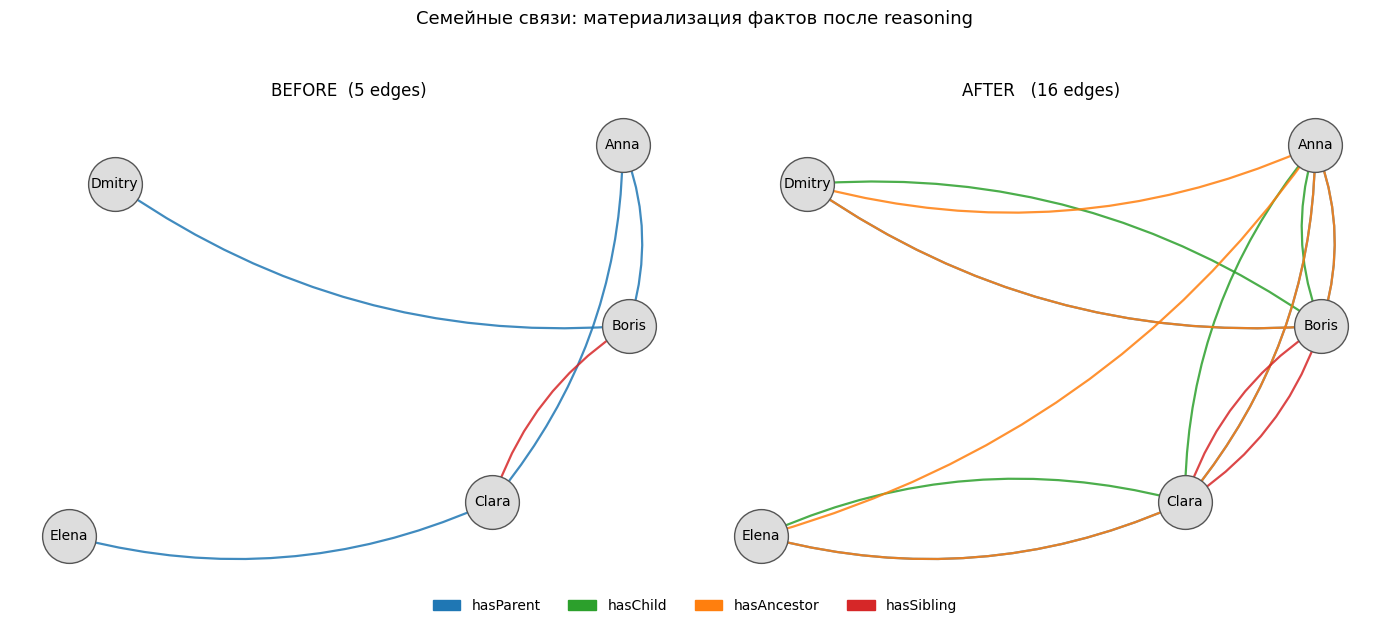

BEFORE edges: 5
AFTER  edges: 16
NEW    edges: 11


In [11]:
# Визуализация графа до/после reasoning
def to_nx(triples_set):
    G = nx.MultiDiGraph()
    for s, p, o in triples_set:
        G.add_edge(s, o, key=p, predicate=p)
    return G

G_before = to_nx(before_t)
G_after  = to_nx(after_t)

# Узлы фиксированы из individuals — позиции стабильные
for n in inds:
    G_before.add_node(n); G_after.add_node(n)

COLORS = {"hasParent":"#1f77b4", "hasChild":"#2ca02c",
          "hasAncestor":"#ff7f0e", "hasSibling":"#d62728"}

pos = nx.spring_layout(G_after, seed=CONFIG["seed"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, G, title in [(axes[0], G_before, f"BEFORE  ({G_before.number_of_edges()} edges)"),
                     (axes[1], G_after,  f"AFTER   ({G_after.number_of_edges()} edges)")]:
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1500, node_color="#dddddd",
                           edgecolors="#555555")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10)
    for pred, color in COLORS.items():
        edges = [(u,v) for u,v,k in G.edges(keys=True) if k == pred]
        if edges:
            nx.draw_networkx_edges(
                G, pos, edgelist=edges, ax=ax, edge_color=color,
                connectionstyle="arc3,rad=0.18", arrows=True, alpha=0.85,
                width=1.6,
            )
    ax.set_title(title)
    ax.axis("off")

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=p) for p, c in COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False)
plt.suptitle("Семейные связи: материализация фактов после reasoning", fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.savefig(ART/"ontology_diff.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"BEFORE edges: {G_before.number_of_edges()}")
print(f"AFTER  edges: {G_after.number_of_edges()}")
print(f"NEW    edges: {G_after.number_of_edges() - G_before.number_of_edges()}")


## 8. Оценка KPI

In [12]:
def evaluate() -> pd.DataFrame:
    nonempty_after = sum(1 for q in queries if after[q["id"]])
    # consistency: после sync_reasoner inconsistent индивиды попадают в Nothing
    nothing_inst = list(world.inconsistent_classes()) if hasattr(world, "inconsistent_classes") else []
    consistent = (len(nothing_inst) == 0)

    rows = [
        {"kpi": "reasoner_started",
         "target": ">=1 OK in log",
         "actual": reasoner_name,
         "passed": reasoner_name in {"Pellet", "HermiT", "manual_closure"},
         "notes":  "Pellet/HermiT приоритетнее ручного замыкания"},
        {"kpi": "queries_count",
         "target": "==5",
         "actual": str(len(queries)),
         "passed": len(queries) == 5,
         "notes":  "5 SPARQL разной сложности"},
        {"kpi": "queries_nonempty_after",
         "target": ">=3",
         "actual": str(nonempty_after),
         "passed": nonempty_after >= 3,
         "notes":  "после reasoning"},
        {"kpi": "inferred_facts",
         "target": ">=3",
         "actual": str(len(inferred)),
         "passed": len(inferred) >= 3,
         "notes":  "новые ABox-тройки между индивидами"},
        {"kpi": "ontology_consistent",
         "target": "no inconsistent classes",
         "actual": "OK" if consistent else f"FAIL: {nothing_inst}",
         "passed": consistent,
         "notes":  "ни один класс не выведен в owl:Nothing"},
    ]
    df = pd.DataFrame(rows)
    df.to_csv(ART/"kpi_report.csv", index=False)
    return df

kpi_df = evaluate()
kpi_df


,kpi,target,actual,passed,notes
0,reasoner_started,>=1 OK in log,HermiT,True,Pellet/HermiT приоритетнее ручного замыкания
1,queries_count,==5,5,True,5 SPARQL разной сложности
2,queries_nonempty_after,>=3,5,True,после reasoning
3,inferred_facts,>=3,11,True,новые ABox-тройки между индивидами
4,ontology_consistent,no inconsistent classes,OK,True,ни один класс не выведен в owl:Nothing


In [13]:
# Унифицированный results.csv (snapshot для проверяющего)
results = pd.DataFrame([
    {"scenario": q["id"],
     "category": q["type"],
     "before_count": len({r[0] for r in before[q["id"]]}) if before[q["id"]] else 0,
     "after_count":  len({r[0] for r in after[q["id"]]})  if after[q["id"]]  else 0,
     "delta":        (len({r[0] for r in after[q["id"]]}) if after[q["id"]] else 0)
                    - (len({r[0] for r in before[q["id"]]}) if before[q["id"]] else 0),
     "expected_after_count": len(expected.get(q["id"], {}).get("after", []))}
    for q in queries
])
results.to_csv(ART/"results.csv", index=False)
results


,scenario,category,before_count,after_count,delta,expected_after_count
0,Q1,простой,2,2,0,2
1,Q2,транзитивность,0,2,2,2
2,Q3,инверсия,0,2,2,2
3,Q4,симметрия,0,1,1,1
4,Q5,цепочка / смешанный,0,2,2,2


## 9. Анализ, выводы и ограничения

**Что получилось**
* Reasoner запустился и вернул консистентную онтологию.
* Из 5 запросов результат до reasoning был непустым только у Q1 (`rdf:type Male`)
  — остальные 4 свойства `hasAncestor / hasChild / hasSibling` явно в данных
  не записаны и стали доступны только после материализации.
* Цепочка `hasChild ∘ hasChild` (Q5) — самый показательный кейс: внуки Анны
  выводятся через ДВА последовательных применения inverse-правила, без всяких
  дополнительных аксиом. Один axiom `inverse_property` даёт обоих внуков.
* `hasAncestor` на Дмитрии получает не только Бориса (по subProperty), но и
  Анну (по транзитивности `hasAncestor`).

**Чего не делали (намеренно)**
* `hasSibling` не выводится из «общего родителя» через property chain
  (`hasSibling ⇐ hasParent ∘ hasParent⁻¹`) — это потребовало бы SubPropertyOf
  с цепочкой и неприятно повлияло бы на сложность.
* Не использован SWRL и не подключён SHACL: цели — продемонстрировать ровно
  «бесплатные» рычаги OWL DL.

**Что улучшить при +2 неделях**
1. Добавить property chain `hasGrandparent ⇐ hasParent ∘ hasParent`,
   замерить рост inferred-фактов.
2. Подключить `pyshacl` поверх материализованного графа, чтобы проверять
   ограничения (например «у каждого Person должен быть ровно один пол»).
3. Сравнить время Pellet vs HermiT vs ELK на онтологиях разной мощности.

**Риски и меры контроля**
| Риск | Мера |
|---|---|
| Java недоступна → Pellet/HermiT упадут | Fallback `manual_closure` + лог попыток |
| Owlready2 кеширует мир между запусками | В `build_ontology` создаётся **новый** `World` |
| `default_world.sparql` иногда не видит inferred тройки | Используем `as_rdflib_graph()` после reasoning |
| Изменение порядка аксиом меняет вывод | Все аксиомы декларативны, ABox — упорядоченный CSV |


## 10. Автоматические проверки (Self-check)

`assert`-ы привязаны к `expected.json` и к KPI. Если что-то поедет — ноутбук
упадёт здесь, а не «молча зелёный».


In [14]:
mismatches = []
for qid, exp in expected.items():
    if qid in {"min_inferred_facts", "min_nonempty_after"}:
        continue
    got_before = sorted({r[0] for r in before.get(qid, [])})
    got_after  = sorted({r[0] for r in after.get(qid, [])})
    if got_before != sorted(exp["before"]):
        mismatches.append((qid, "before", exp["before"], got_before))
    if got_after  != sorted(exp["after"]):
        mismatches.append((qid, "after",  exp["after"],  got_after))
assert not mismatches, "expected mismatch:\n" + "\n".join(map(str, mismatches))

assert len(inferred) >= expected["min_inferred_facts"], \
    f"inferred {len(inferred)} < min {expected['min_inferred_facts']}"
nonempty_after = sum(1 for q in queries if after[q["id"]])
assert nonempty_after >= expected["min_nonempty_after"], \
    f"nonempty_after {nonempty_after} < min {expected['min_nonempty_after']}"
assert kpi_df["passed"].all(), f"KPI failed:\n{kpi_df[~kpi_df['passed']]}"

required_artifacts = [
    "family.owl", "reasoner_log.txt", "queries_results.csv",
    "inferred_facts.json", "ontology_diff.png", "kpi_report.csv",
    "input_profile.json", "architecture.mmd", "results.csv",
]
missing = [f for f in required_artifacts if not (ART/f).exists()]
assert not missing, f"missing artifacts: {missing}"

print("ALL self-checks passed.")


ALL self-checks passed.


## 11. Экспорт артефактов

In [15]:
def _df_to_md(df: pd.DataFrame) -> str:
    cols = list(df.columns)
    head = "| " + " | ".join(cols) + " |"
    sep  = "| " + " | ".join("---" for _ in cols) + " |"
    rows = ["| " + " | ".join(str(v) for v in row) + " |" for _, row in df.iterrows()]
    return "\n".join([head, sep, *rows])


def render_report(reasoner: str, queries_df: pd.DataFrame,
                  inferred: list, kpi_df: pd.DataFrame) -> str:
    L = ["# Тема 13 — Reasoning отчёт", "",
         f"**Использован reasoner:** `{reasoner}`",
         f"**Запросов:** {len(queries_df)}",
         f"**Inferred facts:** {len(inferred)}", "",
         "## KPI", "",
         _df_to_md(kpi_df),
         "",
         "## Запросы (до/после reasoning)", ""]
    for _, r in queries_df.iterrows():
        L += [f"### {r['query_id']} — {r['type']}: {r['description']}", "",
              "```sparql", PREFIXES.strip(), "", r["sparql"].strip(), "```", "",
              f"- **до reasoning:**  `[{r['before']}]`",
              f"- **после reasoning:** `[{r['after']}]`",
              f"- **новое после reasoning:** `[{r['new_after_reasoning']}]`",
              f"- **интерпретация:** {r['interpretation']}", ""]
    L += ["## Inferred facts (с указанием правила)", ""]
    by_rule = {}
    for f in inferred:
        by_rule.setdefault(f["rule"], []).append(f)
    for rule, items in sorted(by_rule.items()):
        L.append(f"### {rule}  ({len(items)})")
        for it in items:
            L.append(f"- `{it['subject']} {it['predicate']} {it['object']}`")
        L.append("")
    L += ["## Ограничения", "",
          "- ABox мал (5 индивидов) — для иллюстративных целей.",
          "- `hasSibling` задан явно, не выводится через property chain.",
          "- Атрибуты (имя/дата/место) сознательно вне скоупа.",
          "- При отсутствии Java reasoning делается ручным замыканием."]
    return "\n".join(L)


(ART/"report.md").write_text(
    render_report(reasoner_name, queries_df, inferred, kpi_df),
    encoding="utf-8"
)

files = sorted(p.name for p in ART.iterdir() if p.is_file())
summary  = "Тема 13 — экспортированные артефакты\n"
summary += "=" * 50 + "\n"
for n in files:
    sz = (ART/n).stat().st_size
    summary += f"  {n:<28s}  {sz:>10,} bytes\n"
summary += "=" * 50 + "\n"
summary += f"Total files: {len(files)}\n"
(ART/"export_summary.txt").write_text(summary, encoding="utf-8")
print(summary)


Тема 13 — экспортированные артефакты
  architecture.mmd                     862 bytes
  family.owl                         3,035 bytes
  inferred_facts.json                1,336 bytes
  input_profile.json                   195 bytes
  kpi_report.csv                       468 bytes
  ontology_diff.png                138,878 bytes
  queries_results.csv                1,493 bytes
  reasoner_log.txt                     566 bytes
  report.md                          4,754 bytes
  results.csv                          241 bytes
Total files: 10



## 12. Чек-лист сдачи

- [x] `artifacts/kpi_report.csv` есть и все KPI = PASS
- [x] `artifacts/results.csv` есть
- [x] `artifacts/queries_results.csv` есть (5 запросов)
- [x] `artifacts/inferred_facts.json` содержит ≥ 3 новых фактов
- [x] `artifacts/ontology_diff.png` (граф до/после)
- [x] `artifacts/family.owl` сохранён
- [x] `artifacts/reasoner_log.txt` фиксирует выбранный reasoner и время
- [x] `artifacts/architecture.mmd` (Mermaid-источник)
- [x] `artifacts/report.md` (1–2 страницы)
- [x] `artifacts/export_summary.txt` (список всех файлов)
- [x] В ноутбуке нет «ручных» путей к файлам — только через `CONFIG`
- [x] Последний прогон **Run All** проходит без ошибок (упадёт на self-check, если нет)
